<a href="https://colab.research.google.com/github/MehdiQurist/-OOP-JDBC/blob/main/Copy_of_Lungyolo11_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Yok")


CUDA available: True
GPU name: Tesla T4


In [ ]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.8 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
files.upload()  # Upload the kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mehdiqurbanov","key":"8bebbe6ac237b92556e02d2977430175"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d younesselbrag/lung-nodules-detection-dataset-annotations
!unzip lung-nodules-detection-dataset-annotations.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/younesselbrag/lung-nodules-detection-dataset-annotations
License(s): other
  0% 0.00/7.03M [00:00<?, ?B/s]
100% 7.03M/7.03M [00:00<00:00, 1.27GB/s]
Archive:  lung-nodules-detection-dataset-annotations.zip
  inflating: dataset/ct_images/images/train/100_jpg.rf.16365de9284134e60df5a3bd27deb600.jpg  
  inflating: dataset/ct_images/images/train/101_jpg.rf.a6277fe5d4daf2fd4b0da35d1aa0791f.jpg  
  inflating: dataset/ct_images/images/train/102_jpg.rf.7179c1bdf001a7d6c7c16051d892eadc.jpg  
  inflating: dataset/ct_images/images/train/103_jpg.rf.7527b9cdfd4d4e5ac18c94f480fc1f7b.jpg  
  inflating: dataset/ct_images/images/train/104_jpg.rf.00e8931e8699adfe18d77d3da9c4a2e4.jpg  
  inflating: dataset/ct_images/images/train/105_jpg.rf.0822aa6696c8ab410e6ae0b0ad6b97a8.jpg  
  inflating: dataset/ct_images/images/train/106_jpg.rf.72f63643d06f2f834ad0c0a3d9143664.jpg  
  inflating: dataset/ct_images/images/train/107_jpg.rf.2b6da1705800b25cdedb4ebce4ba9b89.jpg 

In [ ]:
# Mix and recreate dataset

# Paths to the old training and validation image and label directories
train_dir = Path("dataset/ct_images/images/train")
val_dir   = Path("dataset/ct_images/images/val")
train_lbl = Path("dataset/ct_images/labels/train")
val_lbl   = Path("dataset/ct_images/labels/val")

# New dataset
base_out = Path("dataset/ct_images_split")
for split in ["train", "val", "test"]:
    (base_out / "images" / split).mkdir(parents=True, exist_ok=True)
    (base_out / "labels" / split).mkdir(parents=True, exist_ok=True)

In [ ]:
#   Define the folders
images = list(train_dir.glob("*.jpg")) + list(val_dir.glob("*.jpg"))
labels = list(train_lbl.glob("*.txt")) + list(val_lbl.glob("*.txt"))

#  Get the file names without extensions
image_ids = {img.stem for img in images}
label_ids = {lbl.stem for lbl in labels}

#  Select the common ones (there are 10 extra labels)
common_ids = sorted(image_ids & label_ids)

#  Match the common ones
all_images = [next(img for img in images if img.stem == cid) for cid in common_ids]
all_labels = [next(lbl for lbl in labels if lbl.stem == cid) for cid in common_ids]

In [ ]:
print(f"Total image: {len(all_images)}")
print(f"Total label: {len(all_labels)}")

Total image: 280
Total label: 280


In [ ]:
# Train/Test ayır (örn. %80 / %20)
imgs_train, imgs_test, lbls_train, lbls_test = train_test_split(
    all_images, all_labels, test_size=0.15, random_state=42
)

# Split into Train/Val (let 10% of the training set be used for validation → 0.8 * 0.1 = 0.08, i.e., 8% validation in total)
imgs_train, imgs_val, lbls_train, lbls_val = train_test_split(
    imgs_train, lbls_train, test_size=0.1, random_state=42
)

In [ ]:
# Fonksiyon: kopyala
def copy_files(images, labels, split):
    for img, lbl in zip(images, labels):
        shutil.copy(img, base_out / "images" / split / img.name)
        shutil.copy(lbl, base_out / "labels" / split / lbl.name)

copy_files(imgs_train, lbls_train, "train")
copy_files(imgs_val, lbls_val, "val")
copy_files(imgs_test, lbls_test, "test")

print(f"Train: {len(imgs_train)}, Val: {len(imgs_val)}, Test: {len(imgs_test)}")

Train: 214, Val: 24, Test: 42


In [ ]:
model = YOLO("yolo11n.pt")

model.train(
    data="data.yaml",
    epochs=250,
    patience=50,
    imgsz=640,
    batch=16,
    workers=4,
    device=0
)


Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=250, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2d0d9bc590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import os

def fix_labels(label_dir):
    for filename in os.listdir(label_dir):
        if filename.endswith(".txt"):
            filepath = os.path.join(label_dir, filename)
            with open(filepath, 'r') as f:
                lines = f.readlines()
            with open(filepath, 'w') as f:
                for line in lines:
                    parts = line.split()
                    if parts:
                        # Change class index from 1 to 0
                        parts[0] = '0'
                        f.write(' '.join(parts) + '\n')

# Fix labels in train, val, and test directories
fix_labels(base_out / "labels" / "train")
fix_labels(base_out / "labels" / "val")
fix_labels(base_out / "labels" / "test")

print("Label files updated successfully.")

Label files updated successfully.


In [ ]:
# Post-training evaluation (optional)
metrics = model.val(data="data.yaml", split="val")
print(metrics)

Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 573.1±130.1 MB/s, size: 26.1 KB)
val: Scanning /content/dataset/ct_images_split/labels/val... 24 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 2.1Kit/s 0.0s
val: New cache created: /content/dataset/ct_images_split/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         24         25      0.783        0.6      0.592      0.424
Speed: 4.4ms preprocess, 16.7ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object 

In [ ]:
# Get average results (Precision, Recall, mAP50, mAP50-95)
mp, mr, map50, map = metrics.mean_results()

metrics_dict = {
    "Precision": [mp],
    "Recall": [mr],
    "mAP@0.5": [map50],
    "mAP@0.5:0.95": [map],
}
df = pd.DataFrame(metrics_dict)
print(df)


   Precision  Recall   mAP@0.5  mAP@0.5:0.95
0   0.782677     0.6  0.591896      0.424418


In [ ]:
# Evaluation on the test set
test_metrics = model.val(data="data.yaml", split="test")
print(test_metrics)

Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 502.8±190.0 MB/s, size: 24.4 KB)
val: Scanning /content/dataset/ct_images_split/labels/test... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 2.3Kit/s 0.0s
val: New cache created: /content/dataset/ct_images_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s
                   all         42         43      0.853      0.419      0.537      0.311
Speed: 7.0ms preprocess, 9.4ms inference, 0.1ms loss, 6.4ms postprocess per image
Results saved to /content/runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2d67362ff0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision

In [ ]:
# Get average results (Precision, Recall, mAP50, mAP50-95)
mp, mr, map50, map = test_metrics.mean_results()

metrics_dict = {
    "Precision": [mp],
    "Recall": [mr],
    "mAP@0.5": [map50],
    "mAP@0.5:0.95": [map],
}
df = pd.DataFrame(metrics_dict)
print(df)

   Precision    Recall   mAP@0.5  mAP@0.5:0.95
0   0.853213  0.418605  0.536887      0.311311


In [ ]:
from ultralytics import YOLO

# Burada öz run qovluğunu yaz: train, train2 və s.
run_dir = "runs/detect/train2"

# 1) Best modeli yüklə
model = YOLO(f"{run_dir}/weights/best.pt")

# 2) Validation et
metrics = model.val()

box = metrics.box  # Metric obyekti

# mean_results -> mp, mr, map50, map
mp, mr, map50, map95 = box.mean_results()

print("=====VALIDATION RESULTS (BEST MODEL)=====")
print("Mean Precision:", mp)
print("Mean Recall:", mr)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map95)



Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 594.7±162.0 MB/s, size: 24.5 KB)
val: Scanning /content/dataset/ct_images_split/labels/val.cache... 24 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 42.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s
                   all         24         25      0.783        0.6      0.592      0.424
Speed: 11.1ms preprocess, 6.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val6
=====VALIDATION RESULTS (BEST MODEL)=====
Mean Precision: 0.7826769555403043
Mean Recall: 0.6
mAP@0.5: 0.5918960036781244
mAP@0.5:0.95: 0.42441791795665634


In [ ]:
from ultralytics import YOLO
import pandas as pd

print("Using training directory:", run_dir)

# Load best model
model = YOLO(f"{run_dir}/weights/best.pt")

# Run validation on best.pt
metrics = model.val()
box = metrics.box

val_p = float(box.p)
val_r = float(box.r)
val_map50 = float(box.map50)
val_map95 = float(box.map)

# Read YOLO11 training metrics
df = pd.read_csv(f"{run_dir}/results.csv")

# Select best epoch using highest mAP50(B)
best_epoch = df["metrics/mAP50(B)"].idxmax()

train_p = df["metrics/precision(B)"].iloc[best_epoch]
train_r = df["metrics/recall(B)"].iloc[best_epoch]
train_m50 = df["metrics/mAP50(B)"].iloc[best_epoch]
train_m95 = df["metrics/mAP50-95(B)"].iloc[best_epoch]

# Build comparison table
table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"],
    "Training (B)": [train_p, train_r, train_m50, train_m95],
    "Validation (best.pt)": [val_p, val_r, val_map50, val_map95]
})

print("\n================ YOLO11 PERFORMANCE COMPARISON ================")
print(table.to_string(index=False))
print("===============================================================\n")


Using training directory: runs/detect/train2
Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 510.2±186.5 MB/s, size: 23.9 KB)
val: Scanning /content/dataset/ct_images_split/labels/val.cache... 24 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 27.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s
                   all         24         25      0.783        0.6      0.592      0.424
Speed: 8.5ms preprocess, 6.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val7

================ YOLO11 PERFORMANCE COMPARISON ================
      Metric  Training (B)  Validation (best.pt)
   Precision       0.92721              0.782677
      Recall       0.83333              0.600000
     mAP@0.5

/tmp/ipython-input-3270231556.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val_p = float(box.p)
/tmp/ipython-input-3270231556.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val_r = float(box.r)


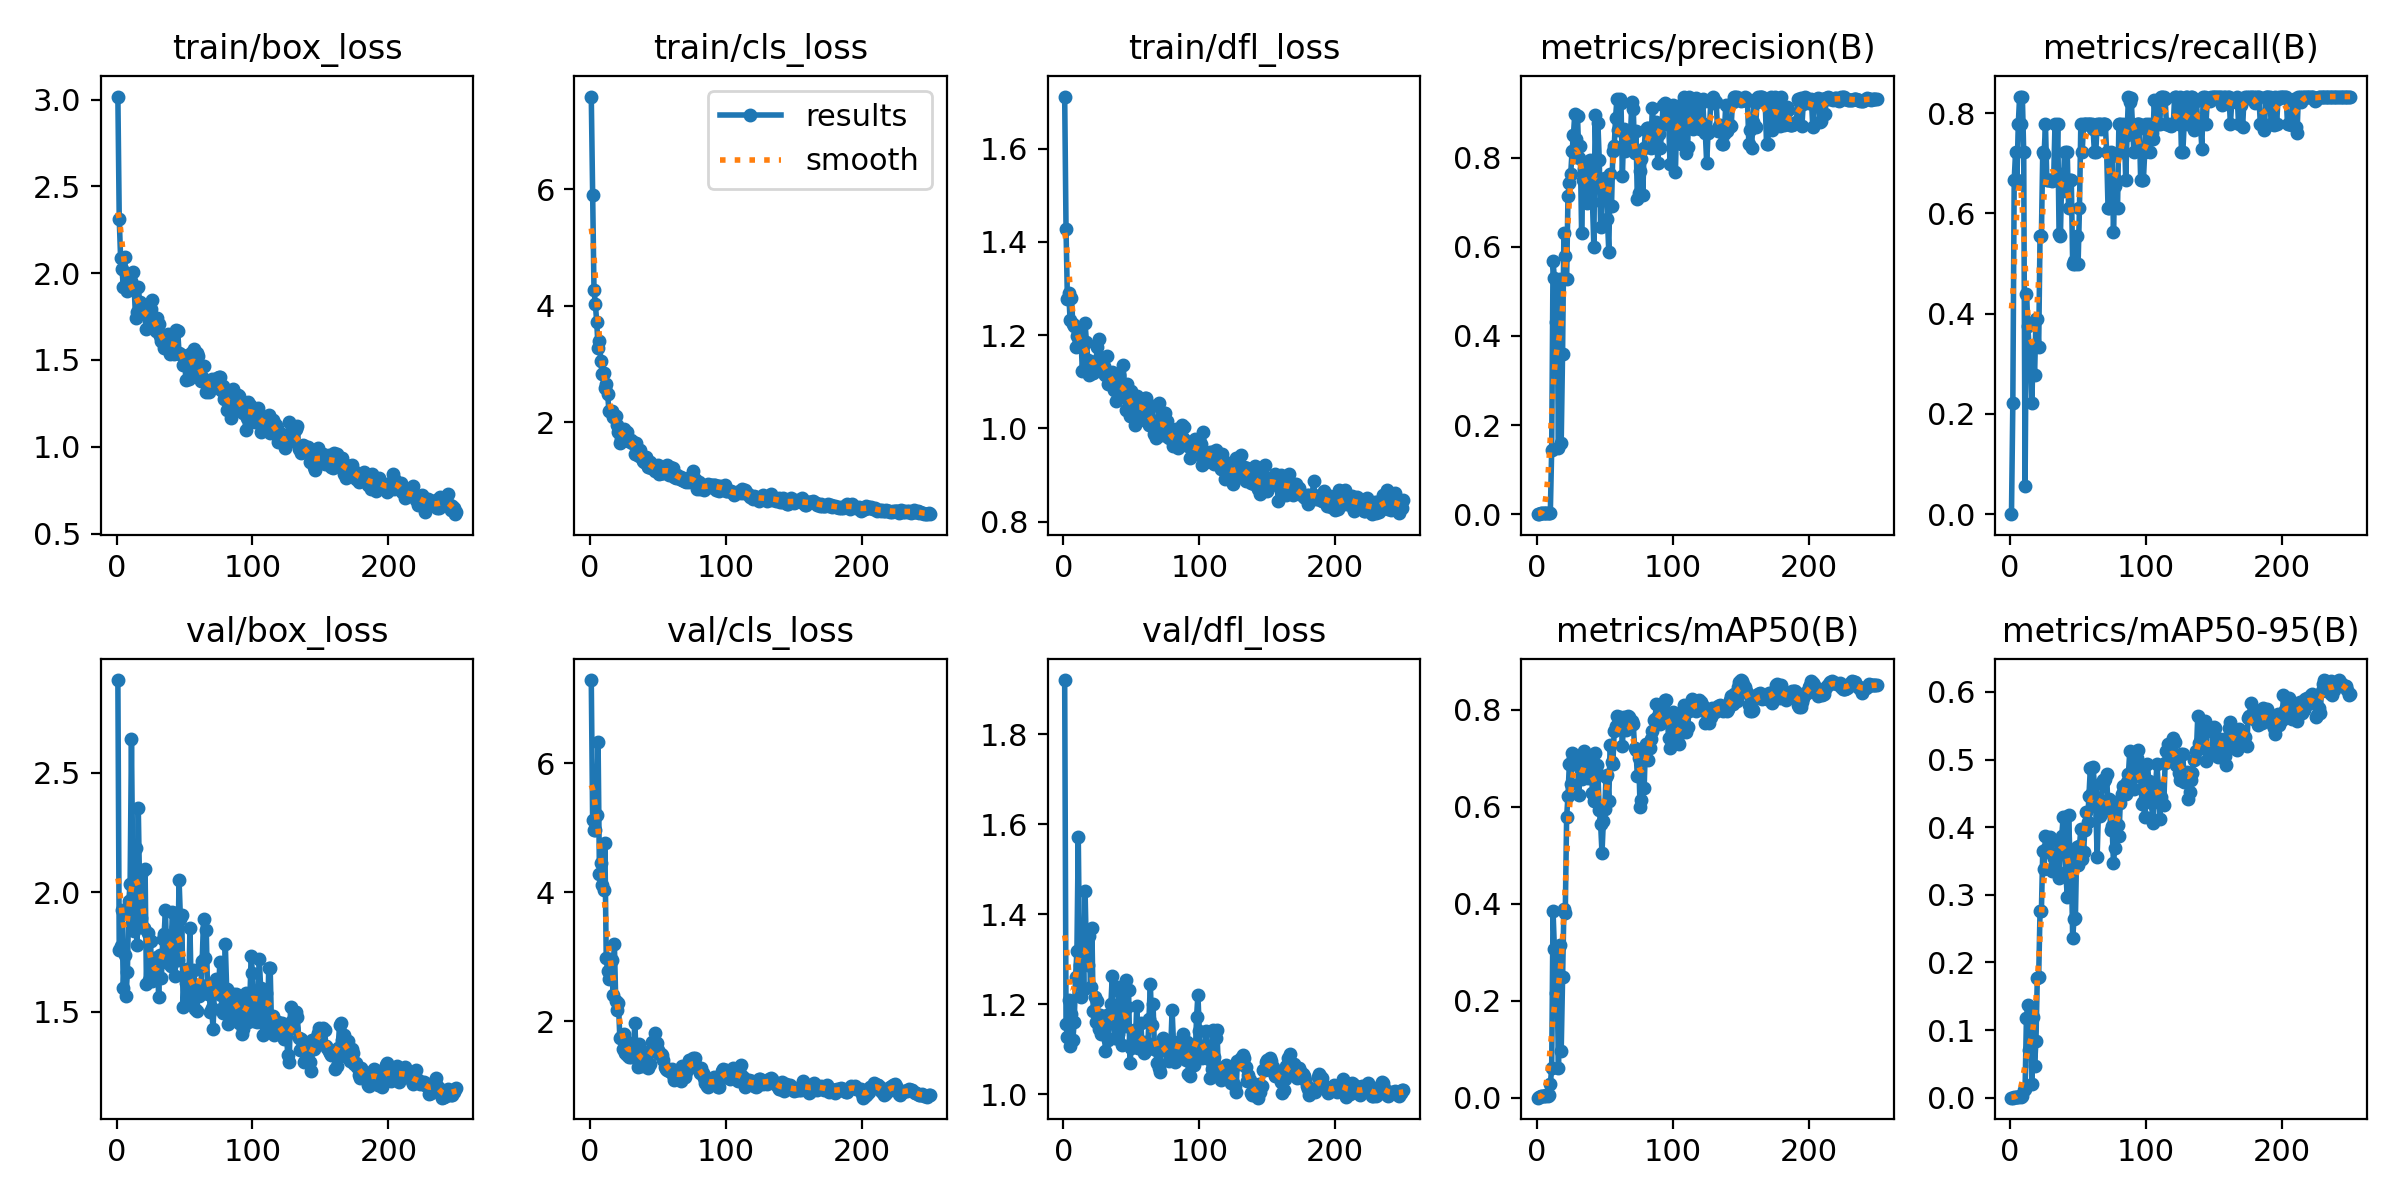

In [ ]:
from IPython.display import Image, display

run_dir = "runs/detect/train2"   # öz train qovluğunu yaz
display(Image(filename=f"{run_dir}/results.png"))
